<a href="https://colab.research.google.com/github/jucavalks/projeto3_ML_siteprojetos/blob/main/projeto3_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

site onde as pessoas postam projetos que elas gostariam. exemplo: "eu gostaria de um site para minha banda de música, contato,etc. eu acho que demora um tanto tal de horas pra fazer (horas_esperadas).. eu pagaria esse (preco)." e o (nao_finalizado) é se alguém aceitou pegar esse projeto para fazer ou não!


In [48]:
import pandas as pd

uri = "projects.csv"
dados = pd.read_csv(uri)
dados.head()

,nao_finalizado,horas_esperadas,preco
0,0,75.0,6985.000000
1,1,0.0,4325.293458
2,0,87.0,14205.000000
3,1,13.0,100.000000
4,0,2.0,202.000000


no nao finalizado: se é 1 = nao finalizado.. seria legal se fosse finalizado = sim (1). então veremos função map: o valor da esquerda da função vira o da direita:

In [49]:
dados["finalizado"] = dados["nao_finalizado"].map({1: 0, 0: 1})
dados.head()

,nao_finalizado,horas_esperadas,preco,finalizado
0,0,75.0,6985.000000,1
1,1,0.0,4325.293458,0
2,0,87.0,14205.000000,1
3,1,13.0,100.000000,0
4,0,2.0,202.000000,1


<Axes: xlabel='horas_esperadas', ylabel='preco'>

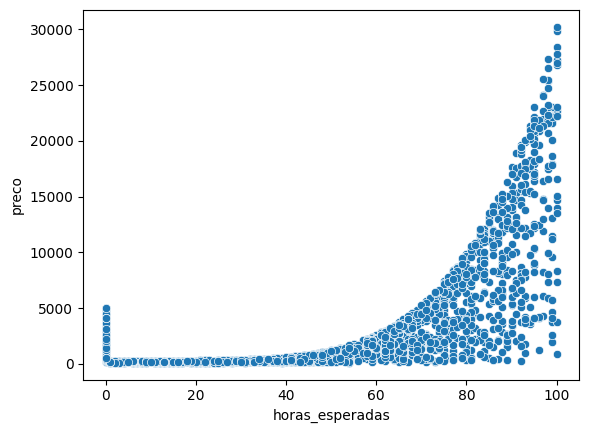

In [50]:
import seaborn as sns

sns.scatterplot(x="horas_esperadas", y="preco", data=dados)

<Axes: xlabel='horas_esperadas', ylabel='preco'>

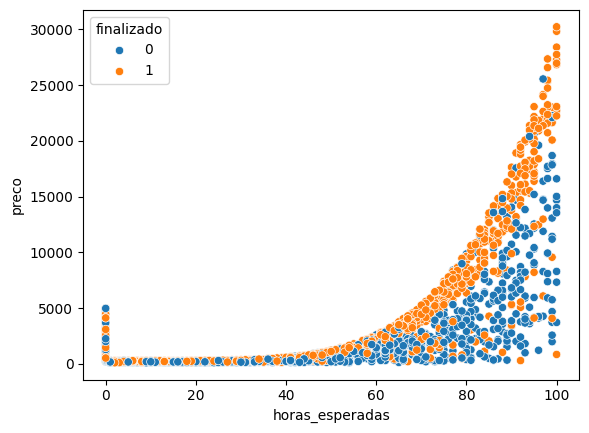

In [51]:
sns.scatterplot(x="horas_esperadas", y="preco", data=dados, hue="finalizado")

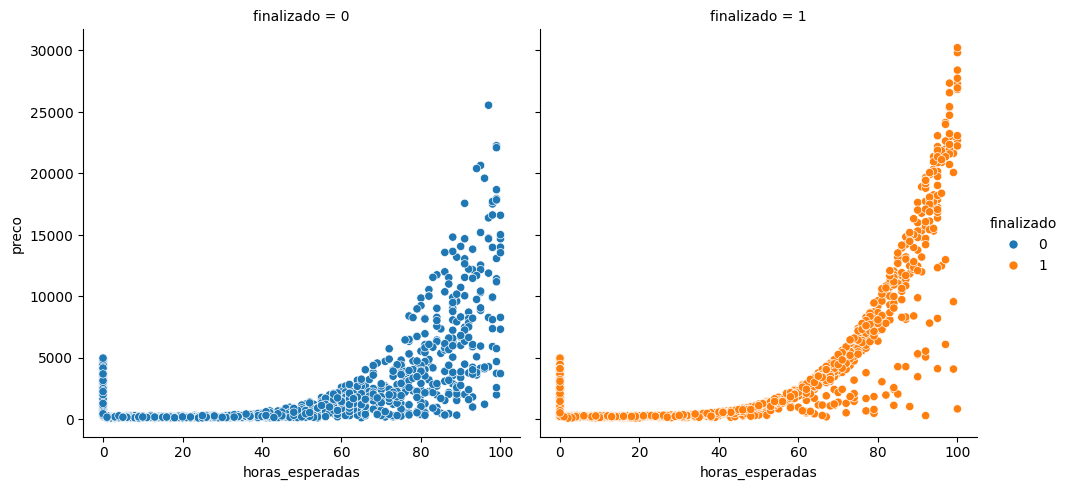

In [52]:
sns.relplot(x="horas_esperadas", y="preco", data=dados, hue="finalizado", col="finalizado")

quero jogar fora as linhas com hora esperada = 0, pq nao faz mt sentido esse finalizados no hora esperada, n tem mt informação:

In [53]:
dados = dados.query("horas_esperadas > 0")
dados.head()

,nao_finalizado,horas_esperadas,preco,finalizado
0,0,75.0,6985.0,1
2,0,87.0,14205.0,1
3,1,13.0,100.0,0
4,0,2.0,202.0,1
5,0,49.0,1096.0,1


In [54]:
x = dados[["horas_esperadas", "preco"]]
y = dados["finalizado"]


In [55]:
dados.shape

(2157, 4)

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score


x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, random_state = 42, test_size = 0.25, stratify = y)

modelo = LinearSVC()
modelo.fit(x_treino, y_treino)
previsoes = modelo.predict(x_teste)

acuracia = accuracy_score(y_teste, previsoes)
print(f"A acurácia foi de {acuracia*100: .2f}  %")

A acurácia foi de  56.30  %


In [57]:
previsoes_de_base = y_teste.sum() / len(y_teste)
print(f"A acurácia do modelo de base foi de {previsoes_de_base*100: .2f}  %")

# base: chuta q todo mundo vai finalizar, quantos realmente finalizaram

A acurácia do modelo de base foi de  52.59  %


Exemplo Prático:Imagine que você está tentando prever se um cliente vai clicar em um anúncio:De 100 clientes de teste (len(y_teste) = 100):56 clientes clicaram (y_teste.sum() = 56).44 clientes não clicaram.A proporção de quem clicou (classe 1) é: $56 / 100 = 0.56$ (ou 56%).O Modelo Base: O modelo de base (baseline) mais ingênuo diria: "Eu chuto que todos os 100 clientes vão clicar, porque a maioria clicou."Se ele chuta que todos clicam, ele acerta 56 vezes.Acurácia Base = $56/100 = 56\%$.Por Que a Acurácia de Base é Importante?Você pode observar no seu screenshot que:Acurácia do Modelo (LinearSVC): 56.71 %Acurácia do Modelo de Base: 56.55 % (Assumindo que 56.55% é a proporção da classe majoritária)Seu modelo LinearSVC obteve apenas $0.16$ pontos percentuais de melhoria em relação a simplesmente chutar a maioria!

<Axes: xlabel='horas_esperadas', ylabel='preco'>

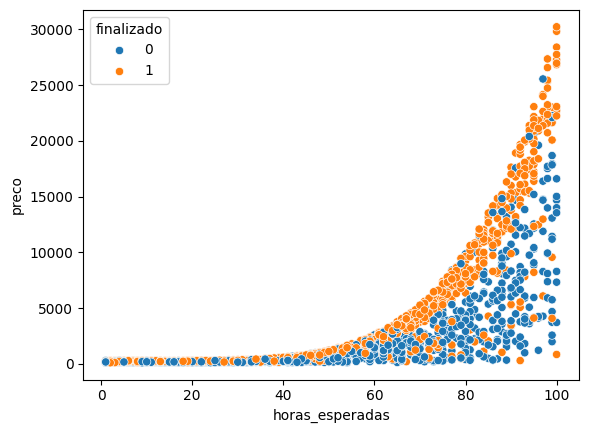

In [58]:
sns.scatterplot(x="horas_esperadas", y="preco", data=dados, hue="finalizado")

seria legal se o modelo conseguisse prever esse espaço em branco tb... chutar 0 ou 1 para qqr par de ponto! então vamos plotar isso junto: plotar o que estou testando e plotar o espaço em branco tbm, tipo "nesse branco alguem finalizaria"

plotar qual valor min e max de x e valor min e max de y?

In [59]:
# min : horas esperadas min e preco min( x min e y min)
# max : horas esperdas max e preco max

x_min = x_teste["horas_esperadas"].min()
x_max = x_teste["horas_esperadas"].max()
y_min = x_teste["preco"].min()
y_max = x_teste["preco"].max()
#pegando o do teste pq o problema ta no teste
print(f"x_min = {x_min}, x_max = {x_max}, y_min = {y_min}, y_max = {y_max}")

x_min = 1.0, x_max = 100.0, y_min = 100.0, y_max = 28398.0


In [60]:
import numpy as np

pixels = 100 #100x100 = 10000, plotar cada um desses pontos

eixo_x = np.arange(x_min, x_max, (x_max - x_min) / pixels)
eixo_y = np.arange(y_min, y_max, (y_max - y_min) / pixels)
#agr preciso juntar os parzinhos dos eixos

In [61]:
xx, yy = np.meshgrid(eixo_x, eixo_y)
pontos = np.c_[xx.ravel(), yy.ravel()]
pontos
#

array([[1.000000e+00, 1.000000e+02],
       [1.990000e+00, 1.000000e+02],
       [2.980000e+00, 1.000000e+02],
       ...,
       [9.703000e+01, 2.811502e+04],
       [9.802000e+01, 2.811502e+04],
       [9.901000e+01, 2.811502e+04]])

In [62]:
Z = modelo.predict(pontos)
Z = Z.reshape(xx.shape)
Z

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(


array([[1, 0, 0, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]])

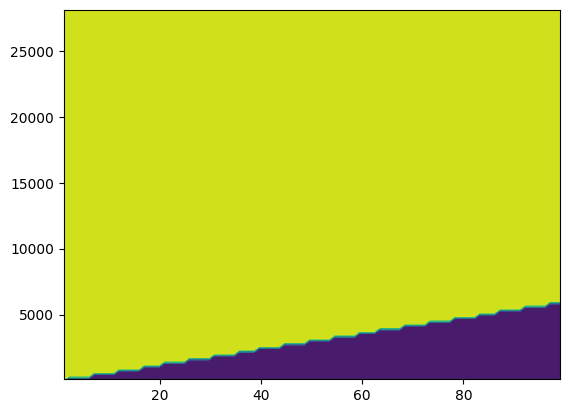

In [63]:
import matplotlib.pyplot as plt

plt.contourf(xx, yy, Z)

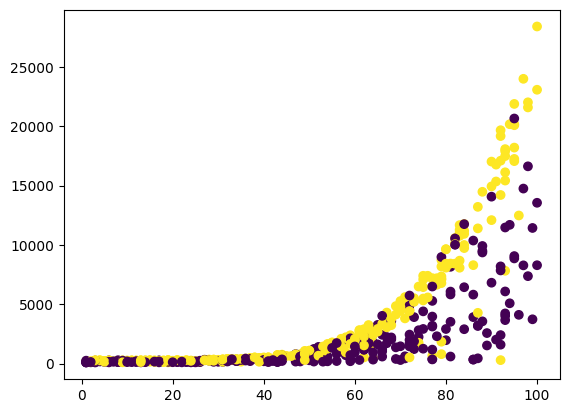

In [64]:
plt.scatter(x_teste["horas_esperadas"], x_teste["preco"], c=y_teste)

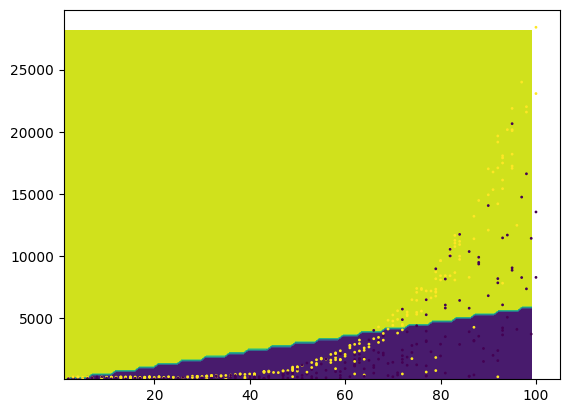

In [67]:
plt.contourf(xx, yy, Z)
plt.scatter(x_teste["horas_esperadas"], x_teste["preco"], c=y_teste, s=1)

vc ve q os graficos n batem, uma reta nao eh boa suficiente. ou seja esse modelo nao consegue aprender pois eh LINEAR!! a relação dessas var eh nao linear ent precisaremos achar um novo modelo!